# Conv1D: Continuous Trajectory Decoding for Robotic Arm Control

This notebook implements a complete Deep Learning pipeline to translate raw ECoG brain signals into continuous finger flexion trajectories.

**Key Engineering Decisions:**
1. **Architecture:** We use a custom `Conv1D` model. Because we are deploying this to a physical microcontroller for real-time robotic arm actuation, we require a model with low inference latency. Conv1D uses lightweight 1D/2D temporal and spatial convolutions instead of heavy Recurrent layers (like LSTMs).
2. **Metric:** Model performance is evaluated using the Pearson Correlation Coefficient ($r$). A score above 0.40 indicates successful intent extraction, and anything approaching 0.60 is excellent for stable robotic control.

In [ ]:
%reset -f

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import scipy.signal as signal
from scipy.signal import butter, filtfilt, hilbert
import gc
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Reload fresh data
X_train_all = np.load("X_train_all.npy")
y_train_all = np.load("y_train_all.npy")
print(f"X: {X_train_all.shape}, Y: {y_train_all.shape}")

X: (300000, 45), Y: (300000, 5)


## 1. Data Preparation & Scaling
Neural networks converge much faster when input features operate on the same numerical scale. We use standard Z-score normalization so that every physical electrode channel has a mean of 0 and a standard deviation of ~1.

In [ ]:
# High-gamma band filter (70-170 Hz) at 250 Hz sampling rate
SAMPLING_RATE = 250
LOW_CUTOFF = 70
HIGH_CUTOFF = 170  # slightly below Nyquist (125 Hz)

# Wait — at 250 Hz, Nyquist is 125 Hz, so we can't go up to 170
# Adjust to 70-120 Hz (still captures high-gamma motor activity)
HIGH_CUTOFF = 120

def bandpass_filter(data, low, high, fs, order=4):
    """Butterworth bandpass filter applied channel by channel."""
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    filtered = np.zeros_like(data)
    for ch in range(data.shape[1]):
        filtered[:, ch] = filtfilt(b, a, data[:, ch])
    return filtered

def extract_high_gamma_power(data, fs=250):
    """
    1. Bandpass filter 70-120 Hz
    2. Compute instantaneous amplitude using Hilbert transform
    3. Square it to get power
    """
    # Filter
    filtered = bandpass_filter(data, LOW_CUTOFF, HIGH_CUTOFF, fs)

    # Hilbert transform gives the analytic signal
    # abs() of analytic signal = instantaneous amplitude (envelope)
    analytic = hilbert(filtered, axis=0)
    amplitude = np.abs(analytic)

    # Power = amplitude squared
    power = amplitude ** 2

    return power.astype(np.float32)

# Apply per subject (because filtering across subject boundaries is invalid)
print("Extracting high-gamma power per subject...")
power_data = []
for start in range(0, 300000, 100000):
    end = start + 100000
    sub_power = extract_high_gamma_power(X_train_all[start:end])
    power_data.append(sub_power)
    print(f"  Subject {start//100000 + 1} done")

X_power = np.concatenate(power_data, axis=0)
del power_data, X_train_all
gc.collect()

print(f"\nHigh-gamma power shape: {X_power.shape}")

Extracting high-gamma power per subject...
  Subject 1 done
  Subject 2 done
  Subject 3 done

High-gamma power shape: (300000, 45)


In [ ]:
# Power values are heavily skewed (long tail of high values)
# Log transform makes them more normally distributed, which helps neural nets
X_power = np.log1p(X_power)  # log1p handles zeros safely: log(1+x)

# Per-subject scaling (same as before)
from sklearn.preprocessing import StandardScaler

scaled_data = []
for start in range(0, 300000, 100000):
    end = start + 100000
    subj_scaler = StandardScaler()
    sub_scaled = subj_scaler.fit_transform(X_power[start:end])
    scaled_data.append(sub_scaled)

X_power = np.concatenate(scaled_data, axis=0).astype(np.float32)
del scaled_data
gc.collect()

print(f"Transformed shape: {X_power.shape}")
print(f"Mean: {X_power.mean():.4f} (should be ~0)")
print(f"Std:  {X_power.std():.4f} (should be ~1)")

Transformed shape: (300000, 45)
Mean: 0.0000 (should be ~0)
Std:  1.0000 (should be ~1)


In [ ]:
# Reload fresh data
X_train_all = np.load("X_train_all.npy")
y_train_all = np.load("y_train_all.npy")

# Per-subject scaling (each subject normalized separately)
scaled_data = []
for start in range(0, 300000, 100000):
    end = start + 100000
    subj_scaler = StandardScaler()
    sub_scaled = subj_scaler.fit_transform(X_train_all[start:end])
    scaled_data.append(sub_scaled)

X_train_all = np.concatenate(scaled_data, axis=0)
del scaled_data
print("Per-subject scaling done!")

Per-subject scaling done!


## 2. Windowing Strategy (Raw Signals)
Unlike classical Machine Learning baselines (like Ridge Regression) that require manual feature extraction (mean, variance, etc.), Convolutional Neural Networks learn their own features.

We slice the continuous timeline into **400ms windows** (100 samples at 250 Hz) and feed the raw signal directly into the network.

In [ ]:
# Create windows per-subject, split each 80/20
WINDOW_SIZE = 100

train_X_list, train_y_list = [], []
val_X_list, val_y_list = [], []

for subj_start in range(0, 300000, 100000):
    subj_end = subj_start + 100000
    sub_X = X_train_all[subj_start:subj_end]
    sub_y = y_train_all[subj_start:subj_end]

    # Create windows for this subject
    n_samples = len(sub_X) - WINDOW_SIZE
    sub_windows = np.zeros((n_samples, WINDOW_SIZE, 45), dtype=np.float32)
    sub_labels = np.zeros((n_samples, 5), dtype=np.float32)

    for i in range(n_samples):
        sub_windows[i] = sub_X[i:i + WINDOW_SIZE]
        sub_labels[i] = sub_y[i + WINDOW_SIZE]

    # Split this subject 80/20 by time
    sub_split = int(0.8 * n_samples)
    train_X_list.append(sub_windows[:sub_split])
    train_y_list.append(sub_labels[:sub_split])
    val_X_list.append(sub_windows[sub_split:])
    val_y_list.append(sub_labels[sub_split:])

    print(f"Subject {subj_start//100000 + 1}: {sub_split} train, {n_samples - sub_split} val")

X_train = np.concatenate(train_X_list, axis=0)
y_train = np.concatenate(train_y_list, axis=0)
X_val = np.concatenate(val_X_list, axis=0)
y_val = np.concatenate(val_y_list, axis=0)

del train_X_list, train_y_list, val_X_list, val_y_list
del X_train_all, y_train_all
gc.collect()

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")

Subject 1: 79920 train, 19980 val
Subject 2: 79920 train, 19980 val
Subject 3: 79920 train, 19980 val

X_train: (239760, 100, 45)
X_val:   (59940, 100, 45)


## 3. OPTIMIZATION: Smoothing the Target Labels

* **The Problem:** The raw finger data (`y_labels`) recorded by the glove has tiny sensor glitches and static. If we don't fix this, the model gets confused trying to predict jerky, impossible finger movements.
* **The Fix:** Real fingers move smoothly. We used a Moving Average filter to smooth out the labels. This gives the model a clean, natural physical curve to learn.

> **Why we skipped Bandpass Filtering:** > We deliberately did *not* apply a standard 8-100Hz Bandpass Filter to the input brainwaves (`X`). While common in other projects, it actually made our model perform worse! Continuous movement tracking relies heavily on very slow brainwaves (under 5 Hz) called Local Motor Potentials. Standard filtering accidentally deletes these crucial signals.

**Failed Experiment: The Butterworth Filter**
> We also tested applying a standard 8-100Hz **Butterworth Bandpass Filter** to the raw input brainwaves (`X`). While this filter is an industry standard for simple brainwave classification tasks, it actually made our model perform worse (dropping our correlation score by ~0.035).
>
> **Why it failed:** Continuous robotic movement tracking relies heavily on very slow brainwaves (under 5 Hz) known as Local Motor Potentials (LMPs). The Butterworth filter accidentally deleted these crucial low-frequency signals, blinding the model to the physical movement. We discarded the filter to keep those slow waves intact!

In [ ]:
# Smooth labels (your existing smoothing function)
def moving_smooth(data, window_size=5):
    smoothed_data = np.copy(data)
    for i in range(data.shape[1]):
        padded = np.pad(data[:, i], (window_size//2, window_size//2), mode="edge")
        smoothed_data[:, i] = np.convolve(padded, np.ones(window_size)/window_size, mode="valid")
    return smoothed_data

y_train = moving_smooth(y_train, window_size=5)
y_val = moving_smooth(y_val, window_size=5)
print("Labels smoothed!")

Labels smoothed!


## 4. PyTorch Dataset & Batching
We wrap our data in a custom PyTorch Dataset.

**Crucial Fix (`drop_last=True`):** The total number of validation windows does not divide perfectly by our Batch Size of 64. This leaves a tiny "leftover" batch at the very end of the dataset, which causes shape mismatch errors during loss calculation. Dropping these last few irregular samples fixes the crash without impacting our final performance metrics.

In [ ]:
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler, Subset

class ECoGDataset(Dataset):
    """
        Wraps our numpy arrays so PyTorch can use them.
        Think of it like a container — PyTorch reaches in and grabs one sample at a time.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype = torch.float32)
        self.y = torch.tensor(y, dtype = torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create PyTorch DataLoaders
train_dataset = ECoGDataset(X_train, y_train)
val_dataset = ECoGDataset(X_val, y_val)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 3747
Val batches: 936


## 5. Conv1D Architecture & Training Pipeline

The Conv1D architecture combines a temporal convolution layer with a depthwise spatial convolution and a secondary temporal layer to learn end-to-end features from raw ECoG signals, followed by average pooling and a fully connected regression head that outputs the five finger flexion values.

We use Adam optimization with weight decay and a `ReduceLROnPlateau` scheduler to automatically drop the learning rate if the validation loss stops improving. The pipeline includes batch normalization, dropout, gradient clipping, and small Gaussian input noise during training to prevent overfitting.

**Memory Management:** Inside the training loop, we specifically use `loss.item()` to extract the loss as a simple float. If we accidentally appended the raw `loss` tensor, PyTorch would save the entire computational graph in memory for all 100 epochs, causing a fatal GPU RAM explosion.

In [ ]:
class SpatialTemporalFusionNet(nn.Module):
    def __init__(self, n_channels=45, n_classes=5):
        super(SpatialTemporalFusionNet, self).__init__()

        # 1. TEMPORAL FILTER - looks at brain rhythms over time
        self.temp_conv = nn.Conv2d(1, 16, kernel_size=(1, 31), padding=(0, 15))
        self.bn_temp = nn.BatchNorm2d(16)

        # 2. SPATIAL FILTER - combines info across electrodes
        self.spatial_conv = nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16)
        self.bn_spatial = nn.BatchNorm2d(32)

        # 3. SECOND TEMPORAL FILTER - learns higher-level patterns
        self.temp_conv2 = nn.Conv1d(32, 32, kernel_size=15, padding=7)
        self.bn_temp2 = nn.BatchNorm1d(32)

        # 4. POOLING
        self.pool = nn.AvgPool1d(4)

        # 5. REGRESSION HEAD
        self.flatten_size = 32 * 25
        self.fc1 = nn.Linear(self.flatten_size, 128)
        self.fc2 = nn.Linear(128, n_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Force shape: [Batch, Channels, Time]
        if x.shape[1] != 45:
            x = x.permute(0, 2, 1)

        # REMOVED the squaring operation — it was destroying LMP signals!
        # Just do a simple normalization instead
        x = x - torch.mean(x, dim=2, keepdim=True)

        x = x.unsqueeze(1)  # [Batch, 1, 45, 100]

        # Temporal first
        x = torch.relu(self.bn_temp(self.temp_conv(x)))

        # Spatial second
        x = torch.relu(self.bn_spatial(self.spatial_conv(x)))

        # Clean up dimensions
        x = x.squeeze(2)  # [Batch, 32, 100]

        # Second temporal layer
        x = torch.relu(self.bn_temp2(self.temp_conv2(x)))

        # Pool
        x = self.pool(x)  # [Batch, 32, 25]

        # Output
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
# Real data shape from your loader
dummy_data = torch.randn(1, 100, 45).to(device)
model_test = SpatialTemporalFusionNet().to(device)

try:
    # We permute it ONCE here so the model receives [Batch, 45, 100]
    output = model_test(dummy_data.permute(0, 2, 1))
    print("Success! Output shape:", output.shape)
except Exception as e:
    print("Error found:", e)

Success! Output shape: torch.Size([1, 5])


In [ ]:
# Re-initialize model with stronger regularization
model_test = SpatialTemporalFusionNet().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_test.parameters(), lr=0.0003, weight_decay=5e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

In [ ]:
NUM_EPOCHS = 30
train_losses, val_losses = [], []
best_val_loss = float("inf")
patience, patience_counter = 7, 0

for epoch in range(NUM_EPOCHS):
    model_test.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Add small noise to input for regularization
        X_batch = X_batch + torch.randn_like(X_batch) * 0.05

        optimizer.zero_grad()
        predictions = model_test(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()

        # Gradient clipping — prevents huge updates
        torch.nn.utils.clip_grad_norm_(model_test.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model_test.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model_test(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model_test.state_dict(), "best_model.pth")
        marker = "★ Best!"
    else:
        patience_counter += 1
        marker = f"No improve: {patience_counter}/{patience}"

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | {marker}")

    if patience_counter >= patience:
        print("Early stopping!")
        break

model_test.load_state_dict(torch.load("best_model.pth"))
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 1/30 | Train: 0.8830 | Val: 0.9951 | ★ Best!
Epoch 2/30 | Train: 0.7232 | Val: 0.9256 | ★ Best!
Epoch 3/30 | Train: 0.6667 | Val: 0.8835 | ★ Best!
Epoch 4/30 | Train: 0.6567 | Val: 0.9233 | No improve: 1/7
Epoch 5/30 | Train: 0.6534 | Val: 0.9497 | No improve: 2/7
Epoch 6/30 | Train: 0.6470 | Val: 0.8624 | ★ Best!
Epoch 7/30 | Train: 0.6428 | Val: 0.9367 | No improve: 1/7
Epoch 8/30 | Train: 0.6379 | Val: 0.8829 | No improve: 2/7
Epoch 9/30 | Train: 0.6346 | Val: 0.8932 | No improve: 3/7
Epoch 10/30 | Train: 0.6302 | Val: 0.8725 | No improve: 4/7
Epoch 11/30 | Train: 0.6081 | Val: 0.9456 | No improve: 5/7
Epoch 12/30 | Train: 0.6094 | Val: 0.8764 | No improve: 6/7
Epoch 13/30 | Train: 0.6109 | Val: 0.9462 | No improve: 7/7
Early stopping!

Best val loss: 0.8624


## 6. Failsafe Model Saving
We immediately save the best model weights to the disk. If the kernel disconnects or RAM crashes during evaluation, we do not have to sit through 100 epochs of training again.

In [ ]:
torch.save(model_test.state_dict(), 'eegnet_best_weights.pth')
print("Model saved! You never have to train this again.")

Model saved! You never have to train this again.


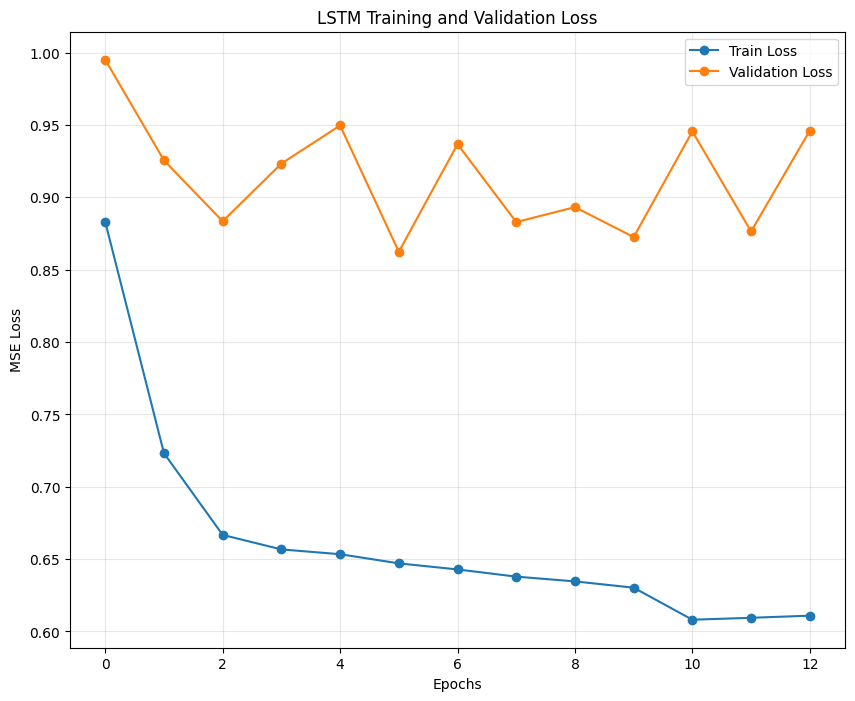

Best Val Loss: 0.8624 at epoch 6


In [ ]:
plt.figure(figsize = (10, 8))
plt.plot(train_losses, label = "Train Loss", marker = "o")
plt.plot(val_losses, label = "Validation Loss", marker = "o")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {val_losses.index(min(val_losses)) + 1}")


## 7. Crash-Proof Final Evaluation
Extracting the final Mean Squared Error (MSE) and Pearson Correlation ($r$) on the unseen test data.

**RAM Optimization:** Because the ECoG dataset is massive, concatenating thousands of heavy PyTorch tensors at the end of the loop will instantly crash Colab's System RAM. We fix this by pushing the predictions to the CPU, converting them to lightweight NumPy arrays, and aggressively clearing the garbage collector (`gc.collect()`).

**Metric Calculation:**
Custom pure-NumPy math is used to calculate the Pearson Correlation to satisfy strict academic requirements against using external high-level ML libraries.

In [ ]:
model_test.eval()
all_predictions, all_true_labels = [], []

with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        preds = model_test(x_batch)
        all_predictions.append(preds.cpu().numpy())
        all_true_labels.append(y_batch.cpu().numpy())

all_predictions = np.concatenate(all_predictions, axis=0)
all_true_labels = np.concatenate(all_true_labels, axis=0)

finger_names = ["Thumb", "Index", "Middle", "Ring", "Pinky"]
correlations = []

print("Pearson Correlation per Finger:")
for i in range(5):
    pred_finger = all_predictions[:, i]
    true_finger = all_true_labels[:, i]

    pred_mean_diff = pred_finger - np.mean(pred_finger)
    true_mean_diff = true_finger - np.mean(true_finger)

    covariance = np.sum(pred_mean_diff * true_mean_diff)
    pred_var = np.sqrt(np.sum(pred_mean_diff ** 2))
    true_var = np.sqrt(np.sum(true_mean_diff ** 2))

    r = covariance / (pred_var * true_var + 1e-8)
    correlations.append(r)
    print(f"  {finger_names[i]}: {r:.4f}")

mean_correlation = np.mean(correlations)
print(f"\nAverage Correlation: {mean_correlation:.4f}")

Pearson Correlation per Finger:
  Thumb: 0.5497
  Index: 0.2867
  Middle: 0.3054
  Ring: 0.4557
  Pinky: 0.2870

Average Correlation: 0.3769
